# 🚗 Pangyo Road Traffic Analysis — Portfolio Notebook
**Dataset:** IEEE DataPort (VISSIM simulation, Pangyo Autonomous Driving Zone, Korea)  
**Author:** Muhammad Azahrul Ramadhan · **Date:** Nov 2025

This notebook performs a clean, visual, and interpretable analysis of mixed-traffic conditions.
It aggregates lane-wise speed/occupancy metrics, builds time-based views, and summarizes key insights
automatically for portfolio presentation.

## 1) Setup & Configuration

In [39]:
import os, warnings, textwrap
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# --------- Configuration ---------
DATA_PATH = "01_DATA_RAW/road_traffic_pangyo.csv"   # <-- adjust if needed
SAVE_PLOTS = True                                   # save figures to 05_OUTPUTS/
OUTPUT_DIR = "05_OUTPUTS"
FIG_DPI = 140

# Style
plt.rcParams.update({
    "figure.figsize": (8, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
})
sns.set_style("whitegrid")

def ensure_out_dir():
    if SAVE_PLOTS:
        os.makedirs(OUTPUT_DIR, exist_ok=True)

def savefig(name):
    """Save current figure if SAVE_PLOTS is True."""
    if SAVE_PLOTS:
        ensure_out_dir()
        path = os.path.join(OUTPUT_DIR, name)
        plt.savefig(path, bbox_inches="tight", dpi=FIG_DPI)
        print(f"💾 Saved: {path}")

print("✅ Setup complete")

✅ Setup complete


## 2) Load & Inspect

In [45]:
# Load
if not os.path.exists(DATA_PATH):
    raise SystemExit(f"❌ File not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print(f"✅ Data loaded: shape={df.shape}")
print("Columns:", list(df.columns))

# Basic types
display(df.head())
display(df.dtypes.to_frame("dtype").T)

✅ Data loaded: shape=(266112, 34)
Columns: ['TIMEINT', 'date', 'LINK_ID', 'DAY', 'VEHS(ALL)_1', 'SPEEDAVGARITH(ALL)_1', 'SPEEDAVGHARM(ALL)_1', 'QUEUEDELAY(ALL)_1', 'OCCUPRATE(ALL)_1', 'VEHS(ALL)_2', 'SPEEDAVGARITH(ALL)_2', 'SPEEDAVGHARM(ALL)_2', 'QUEUEDELAY(ALL)_2', 'OCCUPRATE(ALL)_2', 'VEHS(ALL)_3', 'SPEEDAVGARITH(ALL)_3', 'SPEEDAVGHARM(ALL)_3', 'QUEUEDELAY(ALL)_3', 'OCCUPRATE(ALL)_3', 'VEHS(ALL)_4', 'SPEEDAVGARITH(ALL)_4', 'SPEEDAVGHARM(ALL)_4', 'QUEUEDELAY(ALL)_4', 'OCCUPRATE(ALL)_4', 'VEHS(ALL)_5', 'SPEEDAVGARITH(ALL)_5', 'SPEEDAVGHARM(ALL)_5', 'QUEUEDELAY(ALL)_5', 'OCCUPRATE(ALL)_5', 'VEHS(ALL)_6', 'SPEEDAVGARITH(ALL)_6', 'SPEEDAVGHARM(ALL)_6', 'QUEUEDELAY(ALL)_6', 'OCCUPRATE(ALL)_6']


,TIMEINT,date,LINK_ID,DAY,VEHS(ALL)_1,SPEEDAVGARITH(ALL)_1,SPEEDAVGHARM(ALL)_1,QUEUEDELAY(ALL)_1,OCCUPRATE(ALL)_1,VEHS(ALL)_2,...,VEHS(ALL)_5,SPEEDAVGARITH(ALL)_5,SPEEDAVGHARM(ALL)_5,QUEUEDELAY(ALL)_5,OCCUPRATE(ALL)_5,VEHS(ALL)_6,SPEEDAVGARITH(ALL)_6,SPEEDAVGHARM(ALL)_6,QUEUEDELAY(ALL)_6,OCCUPRATE(ALL)_6
0,900-1200,2024-07-01 0:00,1,1,228,146.24,136.25,247.13,0.3064,196.0,...,198.0,155.52,134.94,179.73,0.7288,3.0,15.91,8.64,95.40,0.2005
1,1200-1500,2024-07-01 0:05,1,1,223,159.91,152.15,229.73,0.2840,215.0,...,198.0,170.08,148.28,200.49,0.3336,2.0,17.71,13.93,13.05,0.0991
2,1500-1800,2024-07-01 0:10,1,1,218,153.16,143.45,245.56,0.2909,205.0,...,187.0,156.51,139.76,254.97,0.2590,7.0,22.75,17.16,62.96,0.5037
3,1800-2100,2024-07-01 0:15,1,1,210,146.01,136.60,134.90,0.2512,181.0,...,173.0,163.14,145.79,247.34,0.3618,6.0,18.42,17.01,77.25,0.3064
4,2100-2400,2024-07-01 0:20,1,1,230,154.16,146.49,230.71,0.2843,193.0,...,197.0,152.93,133.32,247.62,0.5600,5.0,19.04,15.82,58.94,0.4467


,TIMEINT,date,LINK_ID,DAY,VEHS(ALL)_1,SPEEDAVGARITH(ALL)_1,SPEEDAVGHARM(ALL)_1,QUEUEDELAY(ALL)_1,OCCUPRATE(ALL)_1,VEHS(ALL)_2,...,VEHS(ALL)_5,SPEEDAVGARITH(ALL)_5,SPEEDAVGHARM(ALL)_5,QUEUEDELAY(ALL)_5,OCCUPRATE(ALL)_5,VEHS(ALL)_6,SPEEDAVGARITH(ALL)_6,SPEEDAVGHARM(ALL)_6,QUEUEDELAY(ALL)_6,OCCUPRATE(ALL)_6
dtype,object,object,int64,int64,int64,float64,float64,float64,float64,float64,...,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64


In [41]:
def inspect_column(df, col, n=5):
    print(f"\n=== Column: '{col}' ===")
    if col not in df.columns:
        print("⚠️  Not found in DataFrame.")
        return
    s = df[col]
    print(f"dtype        : {s.dtype}")
    print(f"non-null     : {s.notna().sum():,} / {len(s):,}")
    print(f"nulls        : {s.isna().sum():,}")
    # show up to 5 sample values as-is (avoid wide wrap)
    sample = s.head(n).to_list()
    print(f"sample ({n}) : {sample}")
    # unique stats (cap to avoid heavy ops on huge cols)
    nunique = s.nunique(dropna=True)
    print(f"unique (≠NaN): {nunique:,}" + (" (top 5 shown below)" if nunique <= 10 else ""))
    if nunique <= 10:
        print(s.value_counts(dropna=True).head(5))

print(f"Raw DataFrame shape: {df.shape[0]:,} rows × {df.shape[1]:,} cols")

inspect_column(df, "date", n=5)
inspect_column(df, "TIMEINT", n=5)


Raw DataFrame shape: 266,112 rows × 34 cols

=== Column: 'date' ===
dtype        : object
non-null     : 266,112 / 266,112
nulls        : 0
sample (5) : ['2024-07-01 0:00', '2024-07-01 0:05', '2024-07-01 0:10', '2024-07-01 0:15', '2024-07-01 0:20']
unique (≠NaN): 4,032

=== Column: 'TIMEINT' ===
dtype        : object
non-null     : 266,112 / 266,112
nulls        : 0
sample (5) : ['900-1200', '1200-1500', '1500-1800', '1800-2100', '2100-2400']
unique (≠NaN): 4,032


## 3) Time Handling & Feature Engineering

In [46]:
import re
import numpy as np
import pandas as pd

# --- Normalisasi nama kolom (tanpa mengubah nama asli selain spasi pinggir) ---
df.columns = df.columns.str.strip()

# --- Parser TIMEINT: ambil angka sebelum '-' (contoh '900-1200' -> 900 detik) ---
def parse_timeint_series(s: pd.Series) -> pd.Series:
    # ubah ke string, ambil bagian sebelum '-', lalu ambil digit saja
    start_part = s.astype(str).str.split('-', n=1).str[0]
    digits = start_part.str.extract(r'(\d+)', expand=False)
    secs = pd.to_numeric(digits, errors='coerce')
    # anggap unit sudah detik; jika ternyata data menit, ubah di sini: secs = secs * 60
    return secs

seconds_since_midnight = parse_timeint_series(df.get("TIMEINT"))

# --- Buat start_of_day dari 'date' ---
start_of_day = pd.to_datetime(df.get("date"), errors="coerce")

# --- Bangun timestamp: kalau seconds ada -> date + seconds, kalau tidak -> pakai date saja ---
df["timestamp"] = pd.NaT  # siapkan kolom
mask = seconds_since_midnight.notna() & start_of_day.notna()

# untuk baris valid TIMEINT
df.loc[mask, "timestamp"] = (
    start_of_day.loc[mask] + pd.to_timedelta(seconds_since_midnight.loc[mask], unit="s")
)

# fallback: kalau TIMEINT NaN tapi 'date' valid, pakai 'date' saja
mask_fallback = (~mask) & start_of_day.notna()
df.loc[mask_fallback, "timestamp"] = start_of_day.loc[mask_fallback]

# --- Guard: jika masih semuanya NaT, hentikan dengan pesan jelas ---
if df["timestamp"].isna().all():
    raise SystemExit("❌ Tidak dapat membuat timestamp dari kolom 'date' dan/atau 'TIMEINT'.")

# --- Bersihkan, urutkan, dan tambah fitur waktu ---
df = df.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
df["hour"] = df["timestamp"].dt.hour
df["weekday"] = df["timestamp"].dt.day_name()  # .dt.day_name('id') jika locale Indonesia tersedia

# --- Deteksi kolom metrik jika belum didefinisikan ---
try:
    speed_cols
except NameError:
    speed_cols = [c for c in df.columns if "SPEED" in c.upper()]

try:
    occ_cols
except NameError:
    # 'OCCUPRATE' umum di dataset ini; tambahkan "OCC" agar lebih fleksibel
    occ_cols = [c for c in df.columns if ("OCCUPRATE" in c.upper()) or re.search(r'\bOCC\b', c.upper())]

try:
    qdelay_cols
except NameError:
    qdelay_cols = [c for c in df.columns if ("QUEUEDELAY" in c.upper()) or ("QDELAY" in c.upper())]

# --- Ringkasan ---
summary = {
    "rows": len(df),
    "cols": df.shape[1],
    "speed_cols": len(speed_cols),
    "occ_cols": len(occ_cols),
    "qdelay_cols": len(qdelay_cols),
    "time_range": (df["timestamp"].min(), df["timestamp"].max()),
}
summary


{'rows': 266112,
 'cols': 37,
 'speed_cols': 12,
 'occ_cols': 6,
 'qdelay_cols': 6,
 'time_range': (Timestamp('2024-07-01 00:15:00'),
  Timestamp('2024-07-29 00:05:00'))}

## 4) Distribution — Average Speed (All Lanes)

In [49]:
# 1. Temukan semua kolom kecepatan lajur
# Ini akan membuat daftar seperti ['SPEEDAVGARITH(ALL)_1', 'SPEEDAVGARITH(ALL)_2', ...]
speed_cols = [col for col in df.columns if 'SPEEDAVGARITH' in col]

# 2. Hitung rata-rata dari semua lajur tersebut untuk setiap baris
# axis=1 berarti kita menghitung rata-rata secara horizontal (menyamping)
df['speed_mean'] = df[speed_cols].mean(axis=1)

# 3. Cek hasilnya
print("Kolom 'speed_mean' berhasil dibuat. Ini 5 baris pertama:")
print(df['speed_mean'].head())

Kolom 'speed_mean' berhasil dibuat. Ini 5 baris pertama:
0    132.761667
1    202.301667
2    134.653333
3    103.115000
4     85.990000
Name: speed_mean, dtype: float64


💾 Saved: 05_OUTPUTS\01_speed_mean_distribution.png


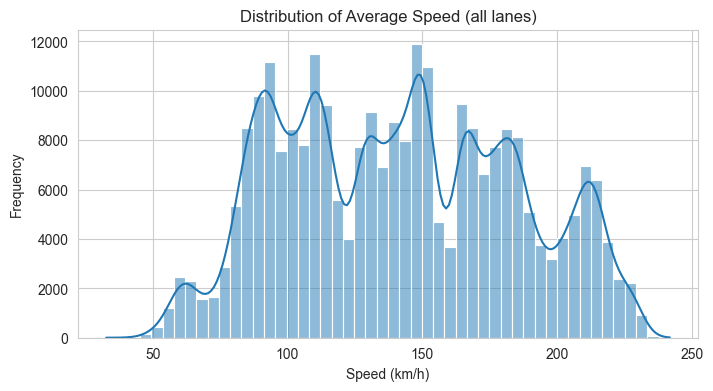

,speed_mean
count,266112.000000
mean,141.561032
std,43.009880
min,32.800000
1%,59.586850
5%,79.493333
25%,105.651250
50%,140.852500
75%,175.700000
95%,213.900000


In [50]:
plt.figure()
sns.histplot(df["speed_mean"], bins=50, kde=True)
plt.title("Distribution of Average Speed (all lanes)")
plt.xlabel("Speed (km/h)"); plt.ylabel("Frequency")
savefig("01_speed_mean_distribution.png")
plt.show()

# Basic stats table
display(df["speed_mean"].describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]).to_frame("speed_mean"))

## 5) Time Series — Speed Over Time

💾 Saved: 05_OUTPUTS\02_timeseries_speed_10min.png


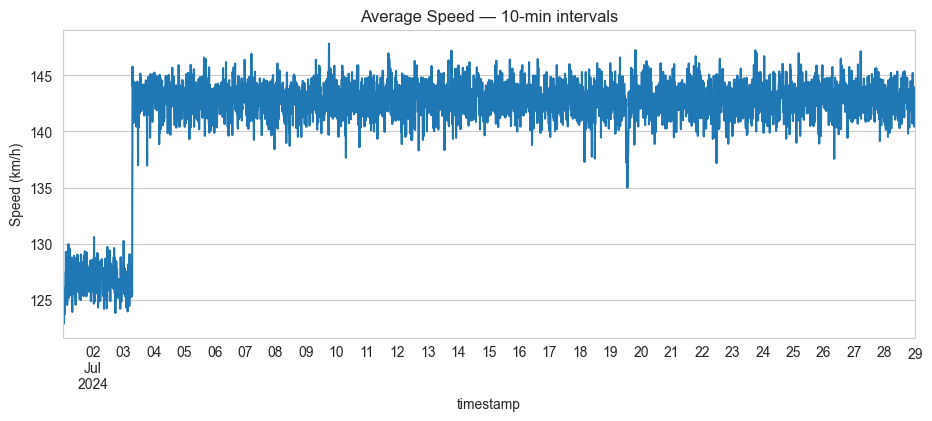

,lowest_speed_windows,speed
0,2024-07-01 01:20:00,124.624436
1,2024-07-01 01:30:00,124.445429
2,2024-07-01 01:40:00,124.651700
3,2024-07-01 01:50:00,124.925387
4,2024-07-01 02:00:00,124.760505
5,2024-07-01 02:10:00,124.896776
6,2024-07-01 02:40:00,125.217180
7,2024-07-02 04:30:00,124.769966
8,2024-07-02 11:20:00,125.223173
9,2024-07-02 21:50:00,125.186010


In [51]:
# Resample to 10-minute averages
ts_10min = df.set_index("timestamp")["speed_mean"].resample("10T").mean()

plt.figure(figsize=(11, 4))
ts_10min.plot()
plt.title("Average Speed — 10-min intervals")
plt.ylabel("Speed (km/h)")
savefig("02_timeseries_speed_10min.png")
plt.show()

# Rush-hour detection (simple: min speed windows)
rolling = ts_10min.rolling(3, min_periods=1).mean()  # 30-min smoothing
low_idx = rolling.nsmallest(10).index.sort_values()
pd.DataFrame({"lowest_speed_windows": low_idx, "speed": rolling.loc[low_idx].values})

## 6) Hourly Profile & Weekday Comparison

💾 Saved: 05_OUTPUTS\03_hourly_speed_profile.png


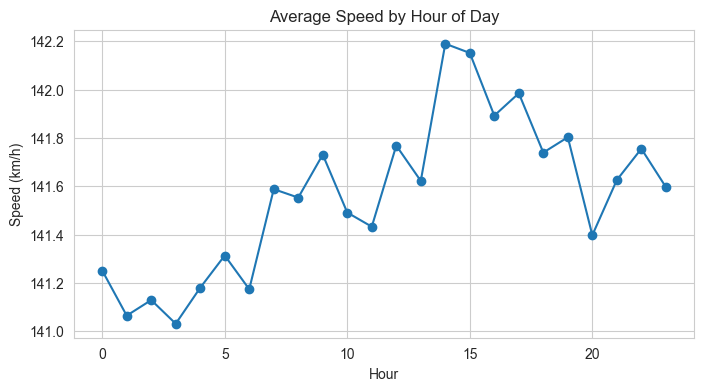

💾 Saved: 05_OUTPUTS\04_weekday_speed_boxplot.png


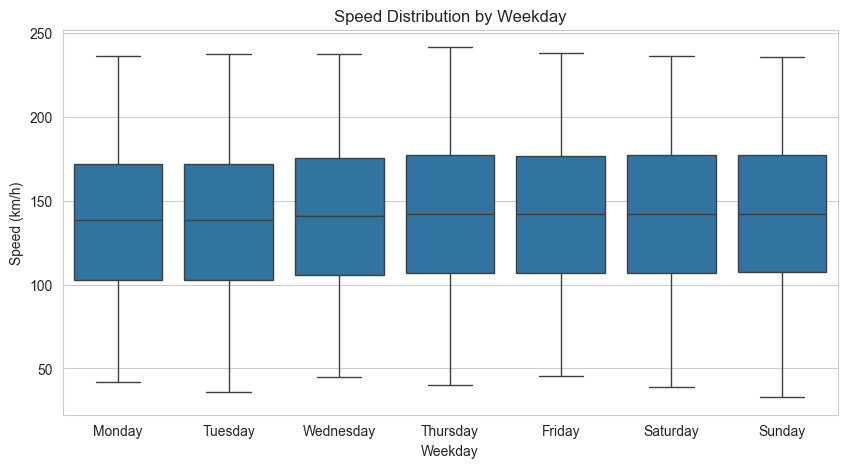

In [52]:
# Hourly profile
hourly = df.groupby("hour")["speed_mean"].mean()

plt.figure()
hourly.plot(marker="o")
plt.title("Average Speed by Hour of Day")
plt.xlabel("Hour"); plt.ylabel("Speed (km/h)")
savefig("03_hourly_speed_profile.png")
plt.show()

# Weekday comparison (if multiple days)
if df["weekday"].nunique() > 1:
    plt.figure(figsize=(10,5))
    sns.boxplot(x="weekday", y="speed_mean", data=df, order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
    plt.title("Speed Distribution by Weekday")
    plt.xlabel("Weekday"); plt.ylabel("Speed (km/h)")
    savefig("04_weekday_speed_boxplot.png")
    plt.show()
else:
    print("ℹ️ Single-day dataset — skipping weekday comparison.")

## 7) Lane-Level Views — Heatmap & Correlation

💾 Saved: 05_OUTPUTS\05_lane_hourly_heatmap.png


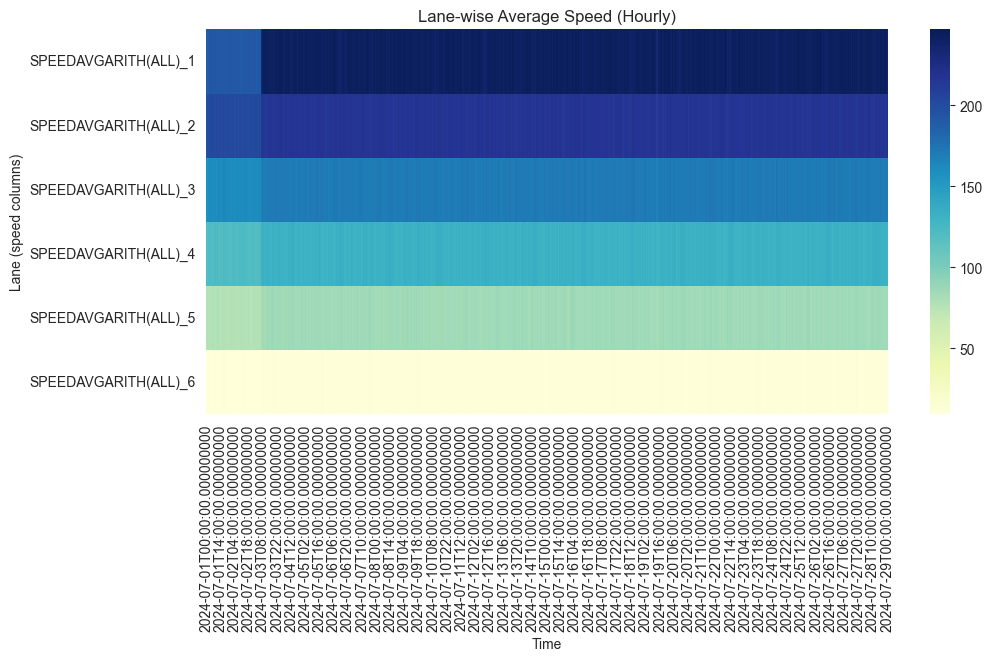

💾 Saved: 05_OUTPUTS\06_lane_speed_correlation.png


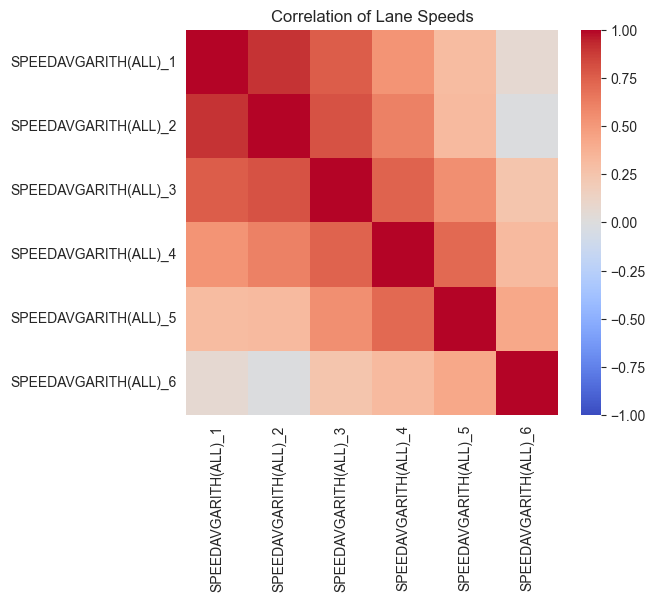

In [53]:
# Build a consistent list of lane speed columns like SPEEDAVGARITH(ALL)_1.._6
lane_cols = [c for c in speed_cols if any(c.endswith(f"_{i}") for i in range(1, 13))]
if not lane_cols:
    # Fallback: use all speed columns
    lane_cols = speed_cols

# Hourly mean per lane
lane_hour = df.set_index("timestamp")[lane_cols].resample("1H").mean()

plt.figure(figsize=(11, 5))
sns.heatmap(lane_hour.T, cmap="YlGnBu")
plt.title("Lane-wise Average Speed (Hourly)")
plt.xlabel("Time"); plt.ylabel("Lane (speed columns)")
savefig("05_lane_hourly_heatmap.png")
plt.show()

# Correlation across lanes
plt.figure(figsize=(6,5))
sns.heatmap(df[lane_cols].corr(), annot=False, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation of Lane Speeds")
savefig("06_lane_speed_correlation.png")
plt.show()

## 8) Relationship — Occupancy vs Speed

In [55]:
# 1. Temukan semua kolom occupancy (okupansi) lajur
occ_cols = [col for col in df.columns if 'OCCUPRATE' in col]

# 2. Hitung rata-rata dari semua lajur tersebut untuk setiap baris
# axis=1 berarti menghitung rata-rata secara horizontal
df['occ_mean'] = df[occ_cols].mean(axis=1)

# 3. Cek hasilnya
print("Kolom 'occ_mean' berhasil dibuat.")
print(df['occ_mean'].head())

Kolom 'occ_mean' berhasil dibuat.
0    0.704900
1    1.002467
2    0.140333
3    0.336450
4    0.156183
Name: occ_mean, dtype: float64


💾 Saved: 05_OUTPUTS\07_occ_vs_speed_scatter.png


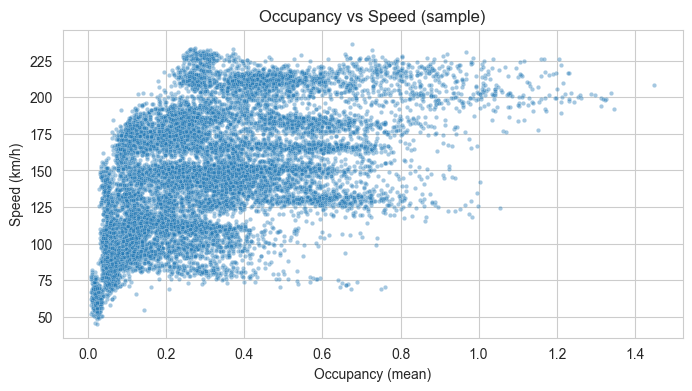

Pearson corr(occ_mean, speed_mean) = 0.583


In [56]:
if df["occ_mean"].notna().any():
    # Sample for speed
    sample = df.sample(min(15000, len(df)), random_state=42) if len(df) > 15000 else df
    plt.figure()
    sns.scatterplot(x="occ_mean", y="speed_mean", data=sample, s=10, alpha=0.4)
    plt.title("Occupancy vs Speed (sample)")
    plt.xlabel("Occupancy (mean)"); plt.ylabel("Speed (km/h)")
    savefig("07_occ_vs_speed_scatter.png")
    plt.show()

    # Simple correlation
    corr = df[["occ_mean","speed_mean"]].corr().iloc[0,1]
    print(f"Pearson corr(occ_mean, speed_mean) = {corr:.3f}")
else:
    print("ℹ️ No occupancy columns found — skipping occupancy vs speed.")

## 9) Queue Delay (Optional)

In [58]:
if df["qdelay_mean"].notna().any():
    plt.figure()
    sns.histplot(df["qdelay_mean"], bins=50, kde=True)
    plt.title("Queue Delay (mean) — Distribution")
    plt.xlabel("Queue Delay"); plt.ylabel("Frequency")
    savefig("08_queue_delay_distribution.png")
    plt.show()

    q_ts = df.set_index("timestamp")["qdelay_mean"].resample("10T").mean()
    plt.figure(figsize=(11, 4))
    q_ts.plot()
    plt.title("Queue Delay — 10-min intervals")
    plt.ylabel("Queue Delay")
    savefig("09_queue_delay_timeseries.png")
    plt.show()
else:
    print("ℹ️ No queue delay columns found — skipping queue delay analysis.")

KeyError: 'qdelay_mean'

## 10) Auto-Insights Summary (Printable)

In [ ]:
insights = []

# Speed stats
sp = df["speed_mean"].describe()
insights.append(f"- Typical average speed ≈ **{sp['50%']:.1f} km/h** (median); variability IQR ≈ {sp['75%']-sp['25%']:.1f} km/h.")

# Rush windows
try:
    low10 = (df.set_index("timestamp")["speed_mean"]
             .resample("10T").mean().rolling(3, min_periods=1).mean()
             .nsmallest(5))
    if len(low10) > 0:
        mins = ", ".join([t.strftime("%Y-%m-%d %H:%M") for t in low10.index])
        insights.append(f"- Slowest windows (congestion-prone): **{mins}**.")
except Exception:
    pass

# Hourly minima/maxima
hourly = df.groupby("hour")["speed_mean"].mean()
hmin, hmax = hourly.idxmin(), hourly.idxmax()
insights.append(f"- By hour: slowest ≈ **{hmin}:00**, fastest ≈ **{hmax}:00**.")

# Occupancy correlation
if df["occ_mean"].notna().any():
    corr = df[["occ_mean","speed_mean"]].corr().iloc[0,1]
    insights.append(f"- Occupancy vs speed correlation: **{corr:.2f}** (negative suggests denser traffic → slower speed).")

# Queue delay
if df["qdelay_mean"].notna().any():
    qd = df["qdelay_mean"].describe()
    insights.append(f"- Queue delay typical level (median): **{qd['50%']:.2f}** (dataset units).")

report = "### Key Insights\n" + "\n".join(insights) + "\n\n" +          "### Next Steps\n" +          "- Segment by **LINK_ID** to localize bottlenecks\n" +          "- Compare lanes (1..6): stability & variance\n" +          "- Evaluate **signal-phase influence** if signal data available\n" +          "- Try ML: **KMeans** for congestion regimes; **RandomForest** for speed prediction\n"

from IPython.display import Markdown, display as _display
_display(Markdown(report))